# TAMPanda + lego-coarse-simple

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import LegoCoarseSimpleSLSBridge, LegoCoarseSimpleV2SLSBridge, execute_plan


## Visualisation helpers
(same as in exercises)

In [2]:
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam

def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img

def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)

def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()

def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25, center=None):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, azimuth, elevation)), title)

def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, 90, -89)), title)

def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)

def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")

print("Visualisation helpers ready \u2713")


Visualisation helpers ready ✓


## Load a task

We load a task using yaml_loader to get the bricks (later used to build TAMPanda scene).

In [3]:
TASK = "dataset/ground_truth/tier1/task_001.yaml"

bricks, lat = load_task(TASK, TASK)
print(f"{len(bricks)} bricks:", [b.name for b in bricks])
bricks

2 bricks: ['4x2_brick_1', '4x2_brick_2']


[Brick(name='4x2_brick_1', type='brick_4x2', color='green', layer=0, yaw=0, cells=frozenset({(-2, 8), (-1, 8), (1, 8), (0, 9), (-1, 9), (-2, 9), (0, 8), (1, 9)}), anchor=(-2, 8), center=(0.0, 0.148, 0.0), initial=(0.3776, -0.114, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_2', type='brick_4x2', color='yellow', layer=1, yaw=0, cells=frozenset({(-2, 8), (-1, 8), (1, 8), (0, 9), (-1, 9), (-2, 9), (0, 8), (1, 9)}), anchor=(-2, 8), center=(0.0, 0.148, 0.0191), initial=(0.2668, -0.1136, 0.0495), initial_yaw=0)]

## Build the scene

`SimpleLegoScene` builds the table + bricks in TAMPanda and sets up PickPlaceExecutor.

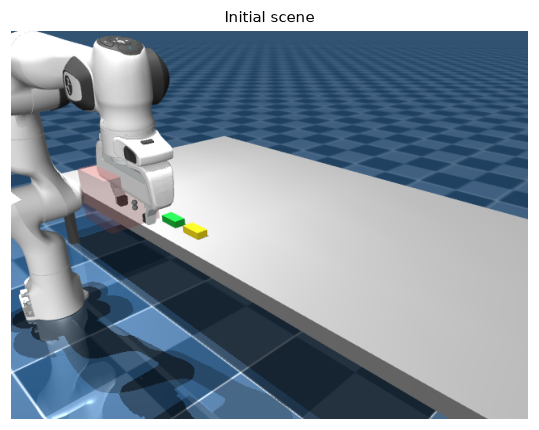

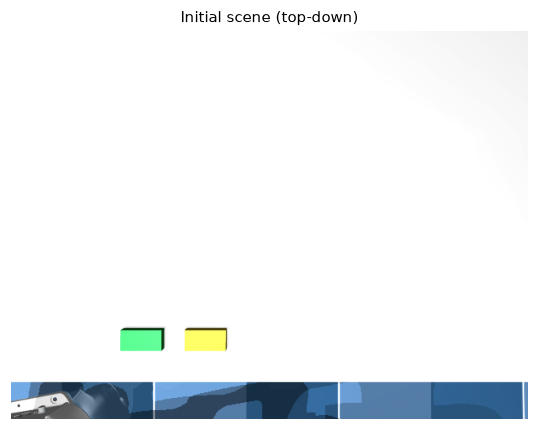

In [4]:
scene = SimpleLegoScene(bricks)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

In [5]:
# TODO: show target scene (frozen) then reset back to initial

## Plan

`build_objects_and_goal` generates the PDDL objects (bricks, locations etc) using the intermediate representation (`bricks`) and also the goal.

In [6]:
bridge = LegoCoarseSimpleSLSBridge.make_bridge("domains/lego_coarse_simple.pddl", scene)
objects, goals = LegoCoarseSimpleSLSBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

plan = bridge.plan(objects, goals)
print("\nPLAN:")
for step in plan:
    print(" ", step)

objects: {'brick': ['b_4x2_brick_1', 'b_4x2_brick_2'], 'location': ['pick_4x2_brick_1', 'pick_4x2_brick_2', 'asm_4x2_brick_1']}
goals:   [('at', 'b_4x2_brick_1', 'asm_4x2_brick_1'), ('stacked_on', 'b_4x2_brick_2', 'b_4x2_brick_1')]
NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.


PLAN:
  ('pick', ('b_4x2_brick_1', 'pick_4x2_brick_1'))
  ('pl

## Execute

Run the plan through `PickPlaceExecutor`, one action at a time, with a render after each step.

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[1/4] pick(b_4x2_brick_1, pick_4x2_brick_1) -> ok


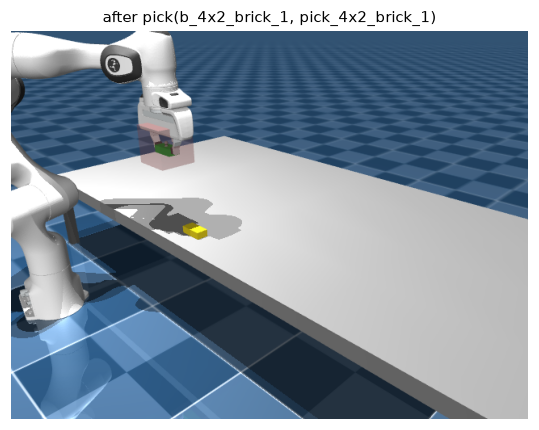

[PickPlaceExecutor] place SUCCESS
[2/4] place(b_4x2_brick_1, asm_4x2_brick_1) -> ok


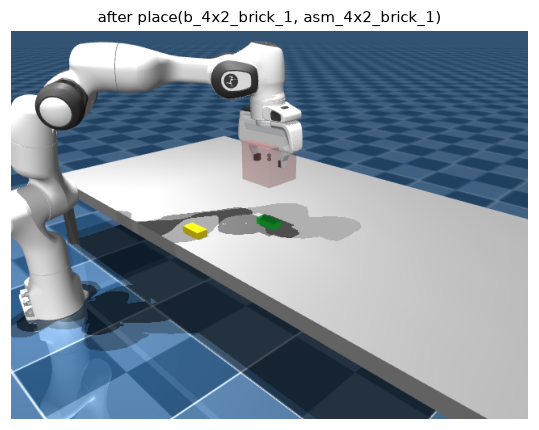

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.2 mm
  pick SUCCESS
[3/4] pick(b_4x2_brick_2, pick_4x2_brick_2) -> ok


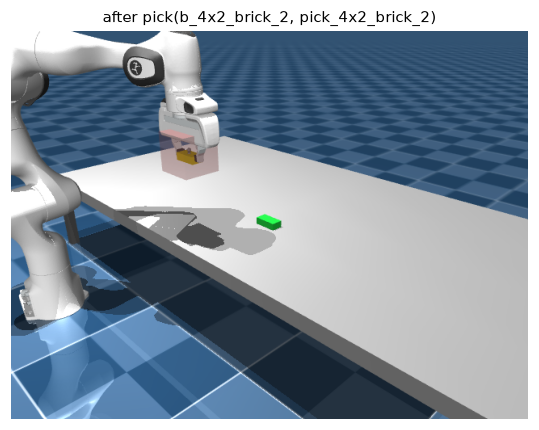

[PickPlaceExecutor] place SUCCESS
[4/4] stack(b_4x2_brick_2, b_4x2_brick_1) -> ok


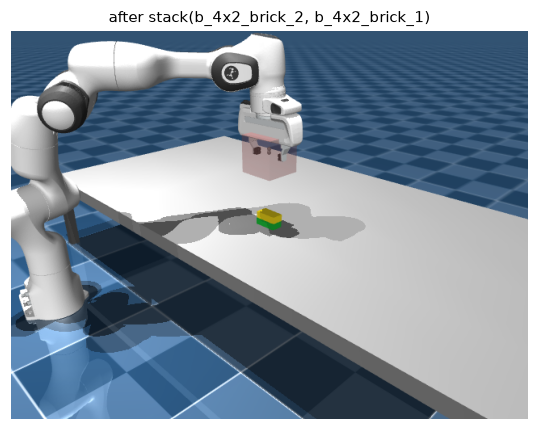


executed: True


In [7]:
start_pos = scene.ee_pos()
ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

## Results

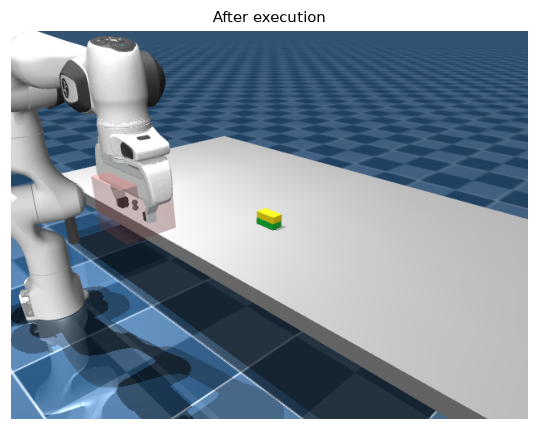

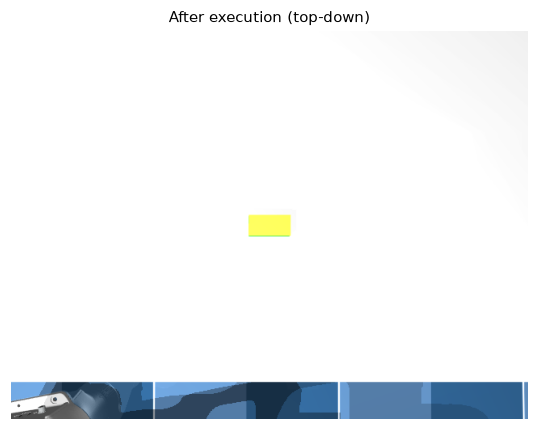

goal reached in sim: True
  4x2_brick_1: xy=  2.1mm  z=  0.4mm  yaw=  0.0deg  OK
  4x2_brick_2: xy=  1.0mm  z=  0.5mm  yaw=  0.1deg  OK


In [8]:
# final arm movement to starting position to get good top-view
path = scene.planner.plan_to_pose(start_pos, scene.executor._last_grasp_quat)
scene.env.execute_path(path, scene.planner)
scene.env.wait_idle()

scene.env.rest(2.0)   # let anything marginal settle before measuring
show_scene(scene.env, "After execution")
show_top_view(scene.env, title="After execution (top-down)")

goal_ok, report = scene.check_goal()
print("goal reached in sim:", goal_ok)
for name, (xy, z, yaw, good) in report.items():
    print(f"  {name}: xy={xy*1000:5.1f}mm  z={z*1000:5.1f}mm  yaw={yaw:5.1f}deg  {'OK' if good else 'MISS'}")

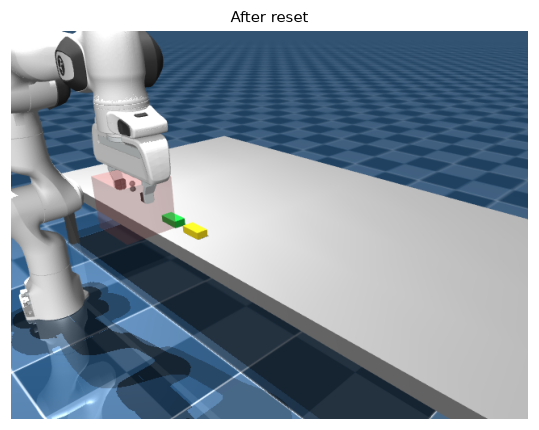

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[1/4] pick(b_4x2_brick_1, pick_4x2_brick_1) -> ok
[PickPlaceExecutor] place SUCCESS
[2/4] place(b_4x2_brick_1, asm_4x2_brick_1) -> ok
[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.2 mm
  pick SUCCESS
[3/4] pick(b_4x2_brick_2, pick_4x2_brick_2) -> ok
[PickPlaceExecutor] place SUCCESS
[4/4] stack(b_4x2_brick_2, b_4x2_brick_1) -> ok


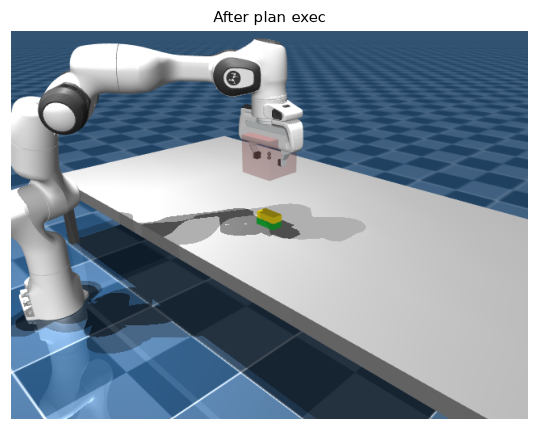

(True,
 {'4x2_brick_1': (np.float64(0.0020992251951982032),
   np.float64(0.00044088433972400143),
   0.050474664995505236,
   True),
  '4x2_brick_2': (np.float64(0.0010410315312176415),
   np.float64(0.0005135510713858982),
   0.1268262869218404,
   True)})

In [9]:
# run again but without rendering
scene.env.reset()
show_scene(scene.env, "After reset")
execute_plan(bridge, plan)
scene.env.rest(2.0)
show_scene(scene.env, "After plan exec")
scene.check_goal()

In [10]:
# viewer = scene.env.launch_viewer()
# scene.env.rest(3.0)   # spin/zoom the window while this runs
# viewer.close()

## Test on Tier 2

In [11]:
TASK = "dataset/ground_truth/tier2/task_001.yaml"

bricks, lat = load_task(TASK, TASK)
print(f"{len(bricks)} bricks:", [b.name for b in bricks])
bricks

3 bricks: ['4x2_brick_1', '2x2_brick_2', '2x2_brick_3']


[Brick(name='4x2_brick_1', type='brick_4x2', color='blue', layer=0, yaw=90, cells=frozenset({(0, 7), (-1, 8), (0, 10), (-1, 7), (0, 9), (-1, 10), (-1, 9), (0, 8)}), anchor=(-1, 7), center=(0.0, 0.148, 0.0), initial=(0.5083, -0.113, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_2', type='brick_2x2', color='green', layer=1, yaw=0, cells=frozenset({(0, 10), (0, 9), (-1, 9), (-1, 10)}), anchor=(-1, 9), center=(0.0, 0.164, 0.0191), initial=(0.374, -0.1168, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_3', type='brick_2x2', color='blue', layer=2, yaw=90, cells=frozenset({(0, 8), (-1, 8), (0, 9), (-1, 9)}), anchor=(-1, 8), center=(0.0, 0.148, 0.0382), initial=(0.2706, -0.1299, 0.0495), initial_yaw=0)]

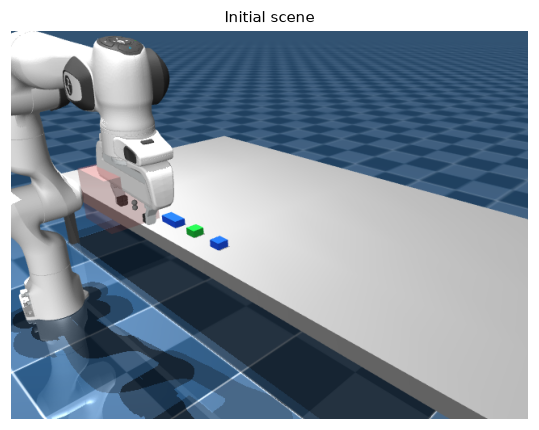

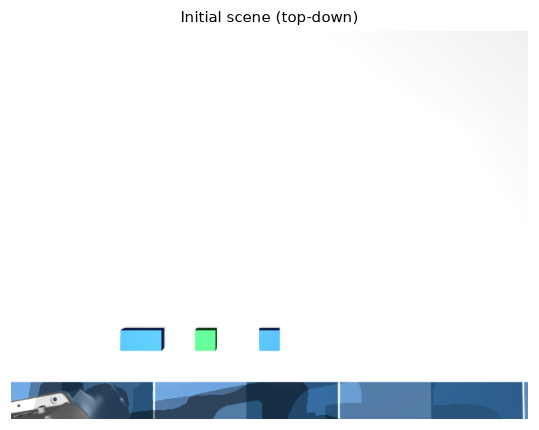

In [12]:
scene = SimpleLegoScene(bricks)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

In [13]:
bridge = LegoCoarseSimpleSLSBridge.make_bridge("domains/lego_coarse_simple.pddl", scene)
objects, goals = LegoCoarseSimpleSLSBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

plan = bridge.plan(objects, goals)
print("\nPLAN:")
for step in plan:
    print(" ", step)

objects: {'brick': ['b_4x2_brick_1', 'b_2x2_brick_2', 'b_2x2_brick_3'], 'location': ['pick_4x2_brick_1', 'pick_2x2_brick_2', 'pick_2x2_brick_3', 'asm_4x2_brick_1']}
goals:   [('at', 'b_4x2_brick_1', 'asm_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_2', 'b_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_3', 'b_2x2_brick_2')]
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.


PLAN:
  ('pick', ('b_2x2_brick_3', 'pick_2x2_brick_3'))
  ('stack', ('b_2x2_brick_3', 'b_2x2_brick_2'))
  ('pick

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[1/10] pick(b_2x2_brick_3, pick_2x2_brick_3) -> ok


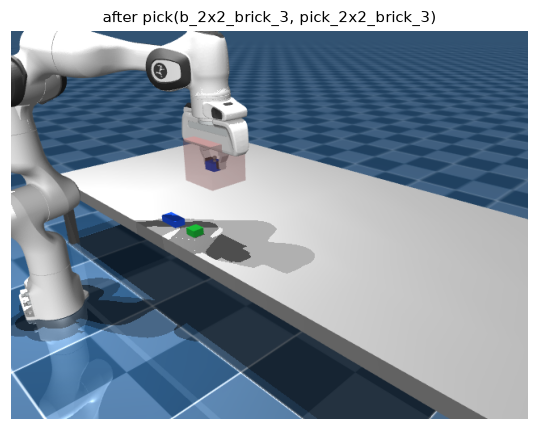

[PickPlaceExecutor] place SUCCESS
[2/10] stack(b_2x2_brick_3, b_2x2_brick_2) -> ok


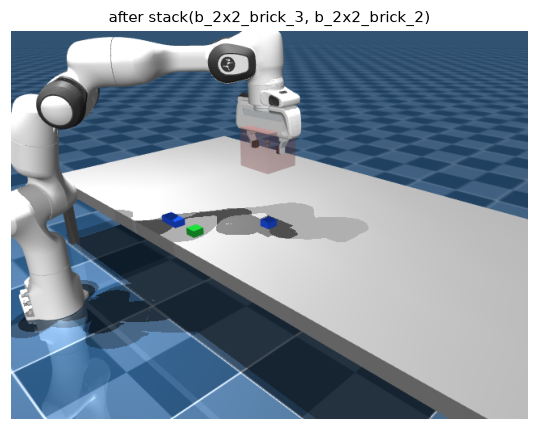

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.5 mm
  pick SUCCESS
[3/10] pick(b_4x2_brick_1, pick_4x2_brick_1) -> ok


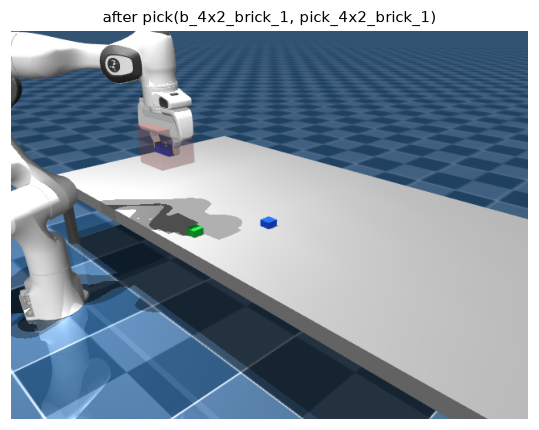

[PickPlaceExecutor] place SUCCESS
[4/10] place(b_4x2_brick_1, asm_4x2_brick_1) -> ok


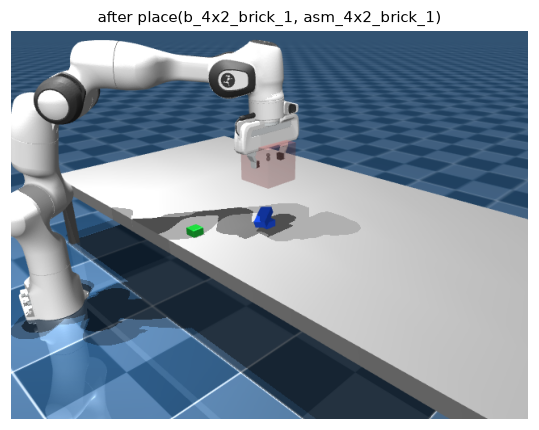

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  lift plan failed — next candidate
[PickPlaceExecutor] Trying candidate 2/2: top_down_y
  approach plan failed — next candidate
[PickPlaceExecutor] All 2 candidates exhausted for 2x2_brick_3
[5/10] unstack(b_2x2_brick_3, b_2x2_brick_2) -> FAILED


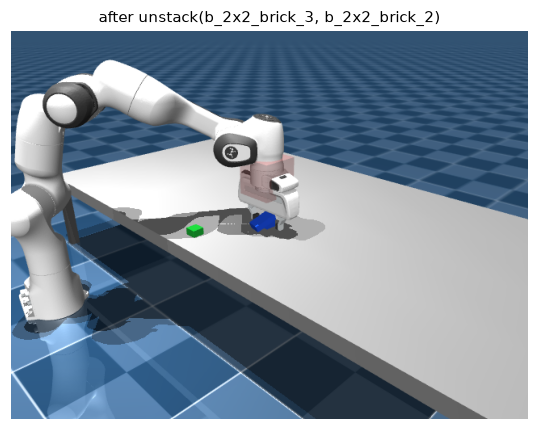


executed: False


In [14]:
start_pos = scene.ee_pos()
ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

### Multiple issues above:
- stack action is wrong: it just places at target position, assuming that supporting block at its target (see action 2/10)
    - fixing this might make above work
- plan is unnecessarily long bc environment is overspecified
    - we should never need to unstack or place outside of target position (working on lego_coarse_simple_v2)
    - especially for tier1/tier2
- no replanning (TAMP) bc we just work with fluents (see LegoCoarseSimpleSLSBridge.make_bridge)
    - fluents have initial values and only get updated by action effects blindly => no re-sensing
    - need predicates that resense their value from environment (see ex4)
        - best way is to use the yaml_loader.Brick representation which builds SimpleLegoScene anyway

## New Even Simpler Domain

In [15]:
# try new domain/bridge

bridge = LegoCoarseSimpleV2SLSBridge.make_bridge("domains/lego_coarse_simple_v2.pddl", scene)
objects, goals = LegoCoarseSimpleV2SLSBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

plan = bridge.plan(objects, goals)
print("\nPLAN:")
for step in plan:
    print(" ", step)

objects: {'brick': ['b_4x2_brick_1', 'b_2x2_brick_2', 'b_2x2_brick_3']}
goals:   [('at-target', 'b_4x2_brick_1'), ('at-target', 'b_2x2_brick_2'), ('at-target', 'b_2x2_brick_3')]
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.


PLAN:
  ('pick', ('b_4x2_brick_1',))
  ('place', ('b_4x2_brick_1',))
  ('pick', ('b_2x2_brick_2',))
  ('stack', ('b_2x2_brick_2', 'b_4x2_brick_1'))
  ('pick', ('b_2x2_brick_3',))
  ('stack', ('b_2x2_brick_3', 'b_2x2_brick_2'))


[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[1/6] pick(b_4x2_brick_1) -> ok


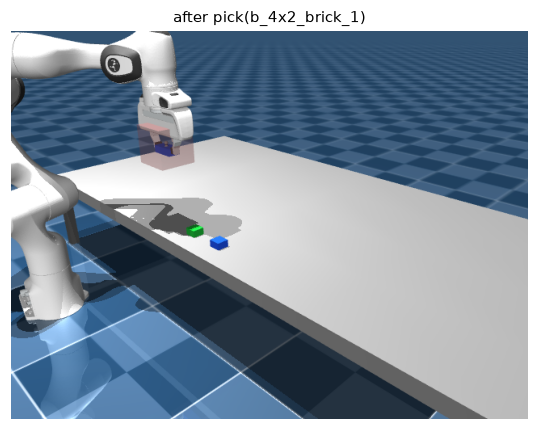

[PickPlaceExecutor] place SUCCESS
[2/6] place(b_4x2_brick_1) -> ok


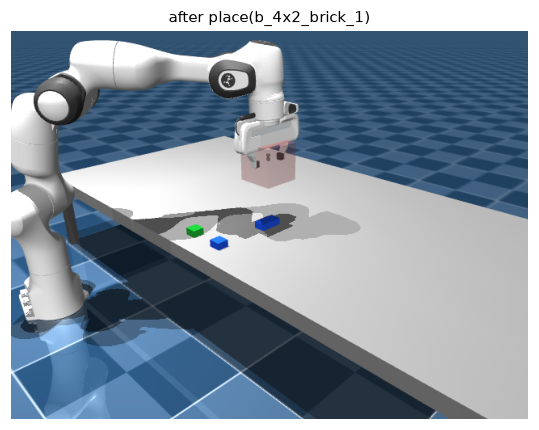

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.0 mm
  pick SUCCESS
[3/6] pick(b_2x2_brick_2) -> ok


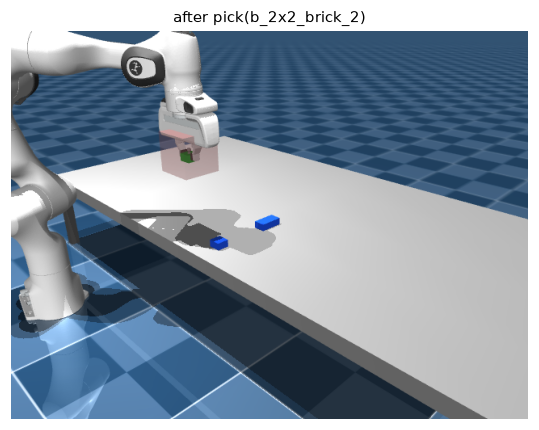

[PickPlaceExecutor] place SUCCESS
[4/6] stack(b_2x2_brick_2, b_4x2_brick_1) -> ok


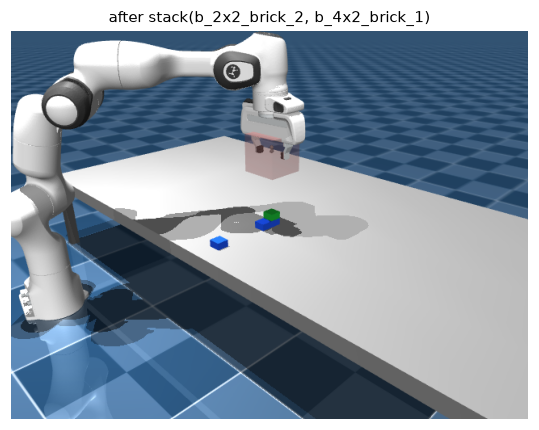

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[5/6] pick(b_2x2_brick_3) -> ok


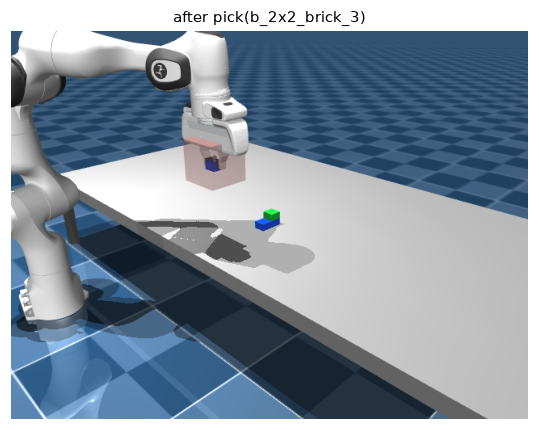

[PickPlaceExecutor] place SUCCESS
[6/6] stack(b_2x2_brick_3, b_2x2_brick_2) -> ok


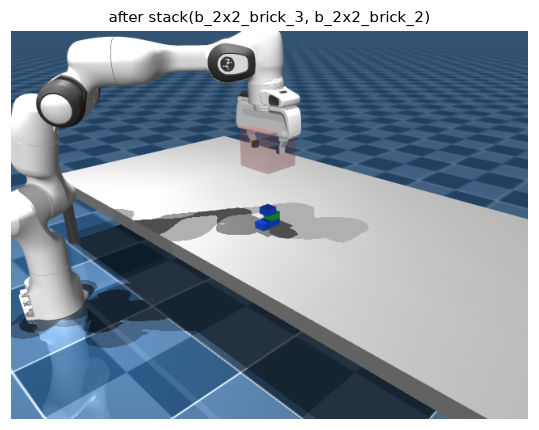


executed: True


In [16]:
scene.env.reset()
scene.env.rest(2.0)

start_pos = scene.ee_pos()
ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

In [17]:
scene.check_goal()

(True,
 {'4x2_brick_1': (np.float64(0.0020510267037401188),
   np.float64(0.0006426031555624157),
   0.21130504425138952,
   True),
  '2x2_brick_2': (np.float64(0.0014279279130926079),
   np.float64(0.0008434912843477971),
   0.06613350763075232,
   True),
  '2x2_brick_3': (np.float64(0.000939241657804843),
   np.float64(0.000996864469093306),
   0.1003868290455614,
   True)})